# Set up

In [19]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [20]:
def power(x, k, b):
    return b * x ** k
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d

def sub_const(ax, q, I, lim):
    ax.plot(q, I, color='black', alpha=0.5)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    mask = q < lim

    x, y = q[mask], (I[mask] - 0.85 * I[mask][-1])
    ax.plot(x,y, color='black', alpha=1)
    return x, y

def sub_power(ax, q, I, lim, A):
    mask = q < lim

    p, cov = curve_fit(power, q[mask], I[mask])

    ax.plot(q[mask],  A * power(q[mask], *p), linestyle='--', color='red')
    x, y = q, I - A * power(q, *p)
    ax.axvline(x = lim, linewidth=0.5, linestyle='--', color='red')
    
    return x, y 
    
def add_porod(ax, x, y, lim, A):
    x_porod = np.linspace(lim, 4, 1000)
    y_porod = x_porod ** -4
    y_porod /= y_porod[0]
    y_porod *= np.mean(y[-10:-1]) / A

    ax.plot(x_porod, y_porod,  alpha = 1, color='black')

    q_full = np.concatenate([x, x_porod])
    I_full = np.concatenate([y, y_porod])

    return q_full, I_full 

def Lorenz(x, y, p = 2):
    return x, y * x ** p

# def parabola_to_zero(x0, y0):
#     a = -y0 / x0**2
#     b = 2*y0 / x0
    
#     def f(x):
#         return a*x**2 + b*x
    
#     return f

# def root_to_zero(x0, y0):
#     a = y0 / (np.sqrt(x0) - x0/(2*np.sqrt(x0)))
#     b = -a/(2*np.sqrt(x0))
    
#     def f(x):
#         return a*np.sqrt(x) + b*x
    
#     return f

# Data

In [50]:
from scipy.fft import dct

def corr_func(q, I, res=1, zmax=None):
    dq = np.diff(q).min()
    dz = 2 * np.pi / q.max() / res
    if zmax == None:
        z = np.arange(dz, 2 * np.pi / dq, dz)
    else:
        z = np.arange(dz, zmax, dz)
    
    K = np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)
    return z, K

def corr_func(q, I, res=1, zmax=None):
    dq = np.diff(q).min()
    dz = 2 * np.pi / q.max() / res
    if zmax == None:
        z = np.arange(dz, 2 * np.pi / dq, dz)
    else:
        z = np.arange(dz, zmax, dz)
    
    K = np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)
    return z, K

C390_S1_3m


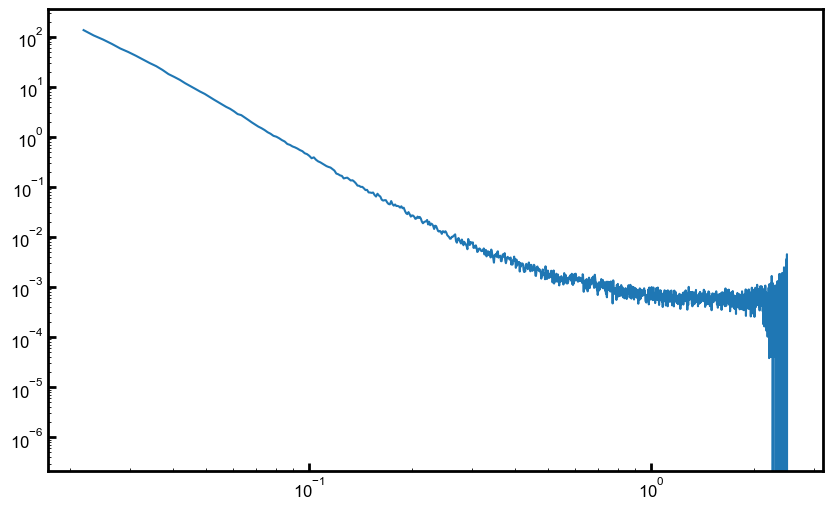

In [51]:
path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00271_00_ave.h5"

Exp = ID02_experiment(path)

Title = Exp.get_Title()
print(Title)

q, I = Exp.get_1d_data()
plt.loglog(q, I)

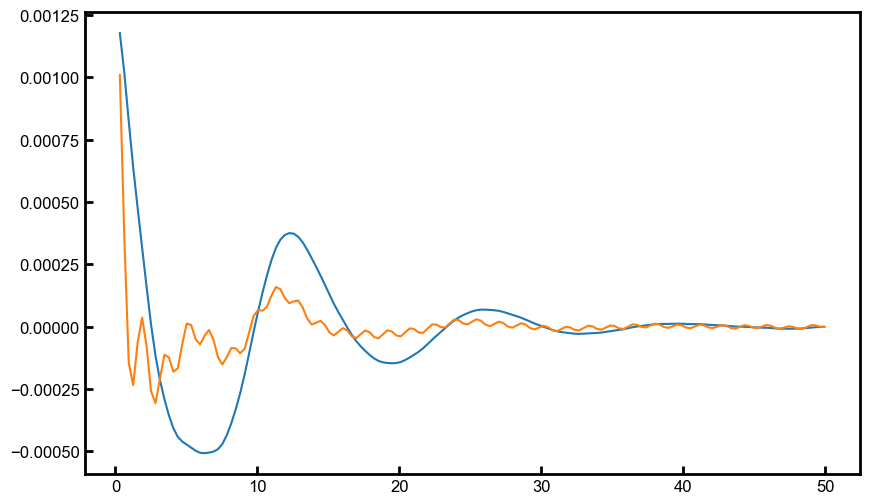

In [52]:
z, K = corr_func(X, Y, res = 5, zmax=50)
plt.plot(z, K)

z, K = corr_func(X, Y * X ** 2, res = 5, zmax=50)
plt.plot(z, K)


### After

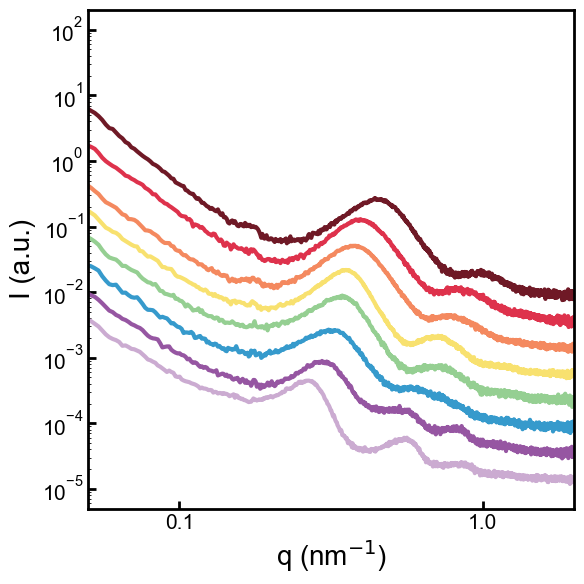

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

scale = 2.5
linewidth = 3

# Ваши данные
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 3, label='after quenching', linewidth=linewidth, color='#6f1926')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 2, label='1000 K/s', linewidth=linewidth, color='#de324c')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 1, label='100 K/s', linewidth=linewidth, color='#f4895f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 0, label='10 K/s', linewidth=linewidth, color='#f8e16f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -1, label='5 K/s', linewidth=linewidth, color='#95cf92')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -2, label='10 K/s', linewidth=linewidth, color='#369acc')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -3, label='0.333 K/s', linewidth=linewidth, color='#9656a2')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -4, label='0.017 K/s', linewidth=linewidth, color='#cbabd1')

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e2)

# Логарифмическая шкала
ax.set_xscale('log')
ax.set_yscale('log')

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
# Отключаем все автоматические тики
ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())  # убираем малые тики

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20 как в вашем примере)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

# Легенда
# ax.legend(fontsize=10, loc=2, frameon=False)

# Размер цифр на тиках
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig(r'E:\C390\Figures\Fig1.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Heating

In [23]:
path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp = ID02_experiment(path)

def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

In [24]:
(96 - 50) + 25

71

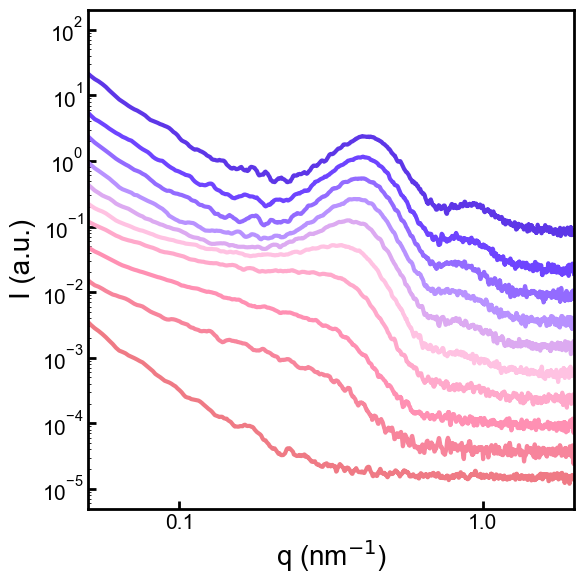

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter

# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

scale = 2.5
linewidth = 3
window = 15

indexes = [i for i in range(0, 10)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 5 * 1.5, color='#5d36e7', linewidth=linewidth)

indexes = [i for i in range(60, 65)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 4, color='#6e44ff', linewidth=linewidth)

indexes = [i for i in range(65, 70)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 3, color='#936bff', linewidth=linewidth)

indexes = [i for i in range(70, 75)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 2, color='#b892ff', linewidth=linewidth)

indexes = [i for i in range(75, 80)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 1, color='#dcaaf1', linewidth=linewidth)

indexes = [i for i in range(80, 85)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** 0, color='#ffc2e2', linewidth=linewidth)

indexes = [i for i in range(85, 90)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** -1, color='#ffa9cb', linewidth=linewidth)

indexes = [i for i in range(90, 95)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** -2, color='#ff90b3', linewidth=linewidth)

indexes = [i for i in range(93, 96)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** -3, color='#f7859c', linewidth=linewidth)

indexes = [i for i in range(100, 110)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
plt.plot(q, I_smooth * scale ** -4, color='#ef7a85', linewidth=linewidth)

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e2)

# Логарифмическая шкала
ax.set_xscale('log')
ax.set_yscale('log')

# НАСТРОЙКА ТИКОВ: ТОЛЬКО 0.1 И 1 (без лишних)
# Отключаем все автоматические тики
ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
ax.xaxis.set_minor_locator(ticker.NullLocator())  # убираем малые тики

# Формат подписей: десятичные числа, без научного формата
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

# Подписи осей (Arial, размер 20 как в вашем примере)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

# Легенда
# ax.legend(fontsize=10, loc=2, frameon=False)

# Размер цифр на тиках
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig(r'E:\C390\Figures\Fig2.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

[]

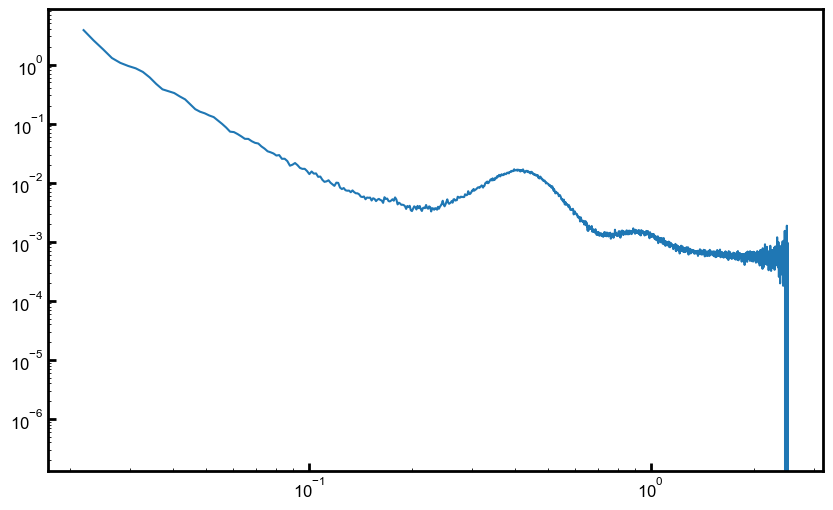

In [26]:
indexes = [i for i in range(5,34)]
q, I = average(Exp,indexes)
plt.plot(q, I)

plt.semilogy()
plt.semilogx()

### Correlation Funcs

In [54]:
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 3, label='after quenching', linewidth=linewidth, color='#6f1926')


L_p =  11.309733552923255
d =  9.385060912235163
Cr =  0.8298215752226437


(-1.1, 1.1)

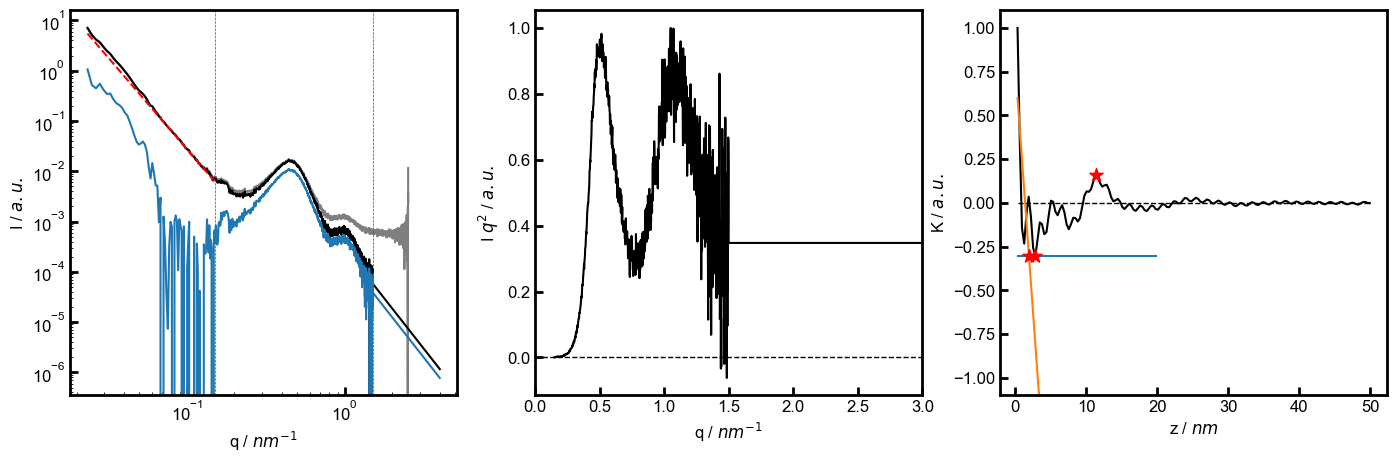

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,5))

size= 100
right = 1.5
left = 0.15
lorenz_power = 4

x, y = sub_const(ax1, q, I, right)
x, y = sub_power(ax1, x, y, left, 0.8)
x_full, y_full = add_porod(ax1, x, y, right, 1)
ax1.plot(x_full, y_full / 1.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('q / $nm^{-1}$')
ax1.set_ylabel('I / $a. u.$')

mask = (x_full > left) 
X, Y = Lorenz(x_full[mask], y_full[mask], p = lorenz_power)

ax2.plot(X, Y / max(Y), label='Lorenz', color='black')
ax2.set_xlim(0, 3)
lnsp = np.linspace(0, max(X))
ax2.plot(lnsp, lnsp * 0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('q / $nm^{-1}$')
ax2.set_ylabel('I $q^2$ / $a. u.$')

z, K = corr_func(X, Y, res = 5, zmax=50)
K /= max(K)
ax3.plot(z, K, color='black')
ax3.plot(z, z * 0, color='black', linewidth=1, linestyle='--')
ax3.set_xlabel('z / $nm$')
ax3.set_ylabel('K / $a. u.$')

mask_max = (z > 7) & (z < 40)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
ax3.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 20)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
ax3.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

ax3.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z < 2
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

ax3.plot(z[mask_min], linear(z[mask_min], *p))


z_d = (K_min - p[1]) / p[0]
ax3.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)
print('Cr = ', 1 - z_d / z_max)

ax3.set_ylim(-1.1, 1.1)

(-0.0005072696913992009, 0.0011778446233661787)

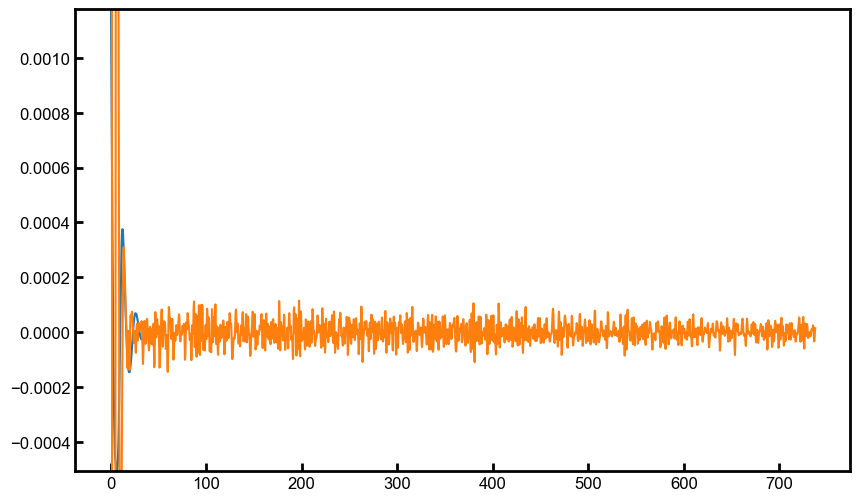

In [43]:
z, K = corr_func(X, Y, res = 5, zmax=50)
plt.plot(z, K)

z1, K1 = cosine_transform(X, Y)
plt.plot(z1, K1)
plt.ylim(min(K), max(K))

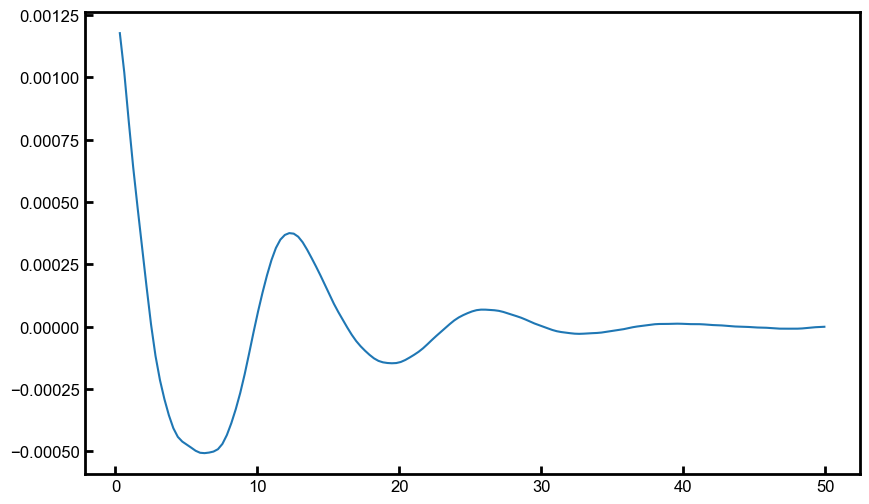

In [34]:
plt.plot(z, K)
# plt.plot(z, np.gradient(np.gradient(K)))

L_p =  12.252211349000193
d =  8.75548965648718
Cr =  0.714604850266613


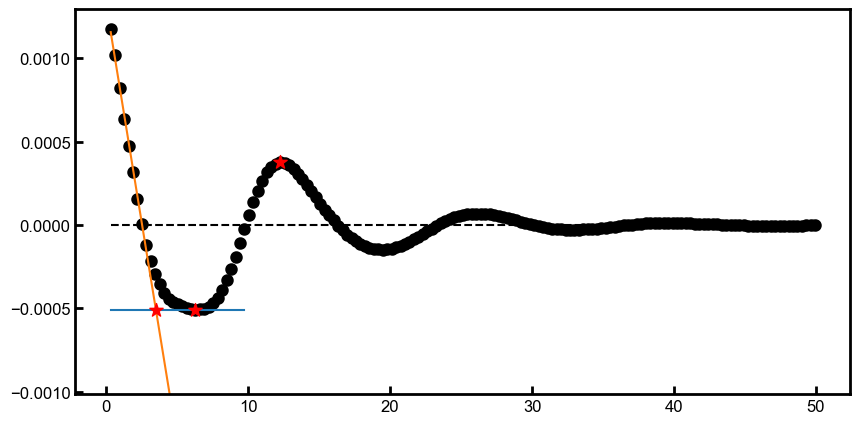

In [13]:
size = 100
plt.figure(figsize=(10,5))
plt.scatter(z, K, linewidth=3, color='black')
plt.plot(z, np.zeros(len(z)), linestyle='--', color='black')

mask_max = (z > 7) & (z < 25)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
plt.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 10)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
plt.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

plt.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z < 3
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

plt.plot(z[mask_min], linear(z[mask_min], *p))

plt.ylim(K_min * 2, max(K) * 1.1)

z_d = (K_min - p[1]) / p[0]
plt.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)

print('Cr = ', 1 - z_d / z_max)

In [15]:
path = r"E:\C390\Autocorrelation function\after_100K_s.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='	')

q, I = np.array(df['q']), np.array(df['I'])

[]

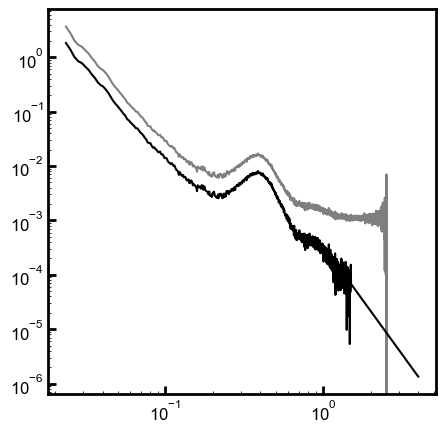

In [16]:
lim = 1.5
mask = q < lim

x, y = q[mask], (I[mask] - 0.85 * I[mask][-1])

x_porod = np.linspace(lim, 4, 1000)

y_porod = x_porod ** -4
y_porod /= y_porod[0]
y_porod *= np.mean(y[-5:-1]) / 1.5

q_full = np.concatenate([x, x_porod])
I_full = np.concatenate([y, y_porod])

plt.figure(figsize=(5,5))
plt.plot(q_full, I_full, zorder=1, alpha = 1, color='black')
plt.plot(q, I * 2, color='black', zorder=0, alpha=0.5)

plt.semilogx()
plt.semilogy()

(0.0, 2.0)

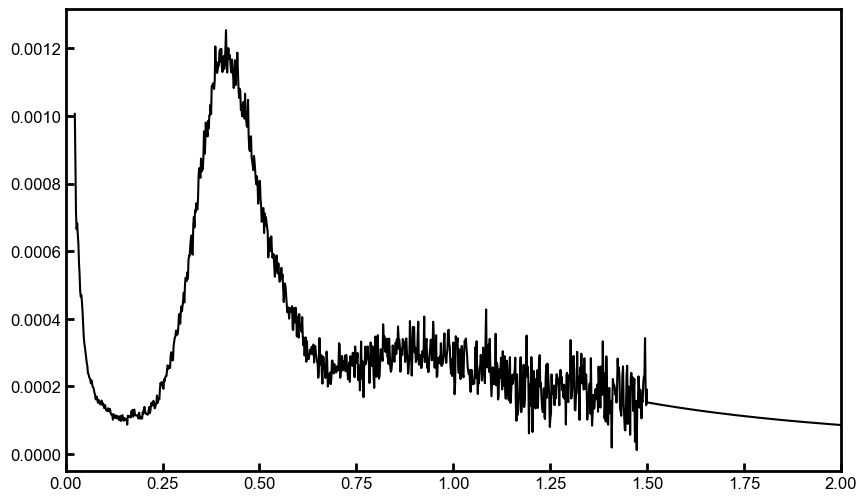

In [17]:
X, Y = q_full, I_full * q_full ** 2
plt.plot(X, Y, color='black')
plt.xlim(0, 2)

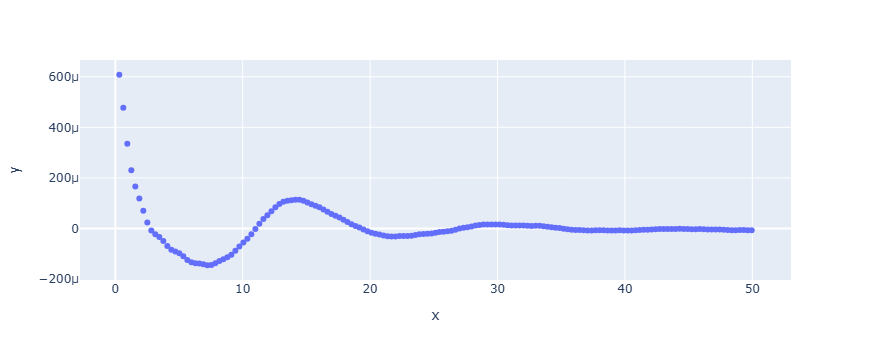

In [18]:
z, K = corr_func(X, Y, res = 5, zmax=50)
px.scatter(x=z, y=K)

L_p =  14.137166941154069
d =  11.56147868576246
Cr =  0.8178073254625268


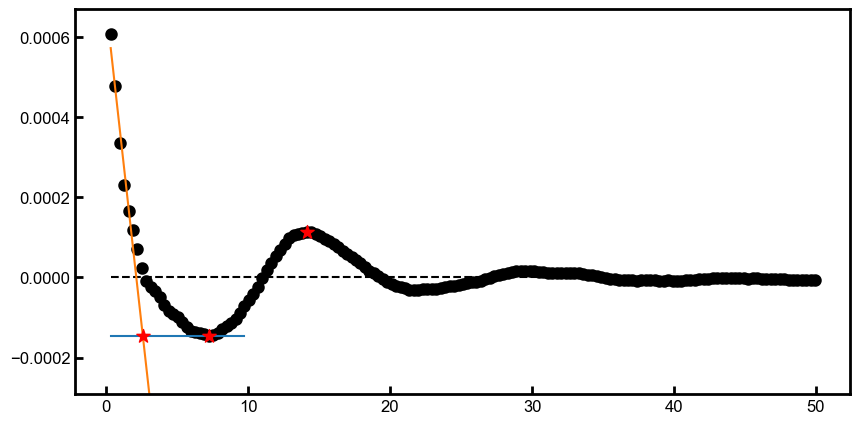

In [19]:
size = 100
plt.figure(figsize=(10,5))
plt.scatter(z, K, linewidth=3, color='black')
plt.plot(z, np.zeros(len(z)), linestyle='--', color='black')

mask_max = (z > 7) & (z < 25)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
plt.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 10)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
plt.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

plt.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z < 2
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

plt.plot(z[mask_min], linear(z[mask_min], *p))

plt.ylim(K_min * 2, max(K) * 1.1)

z_d = (K_min - p[1]) / p[0]
plt.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)

print('Cr = ', 1 - z_d / z_max)

In [20]:
path = r"E:\C390\Autocorrelation function\after_1K_s.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='	')

q, I = np.array(df['q']), np.array(df['I'])

[]

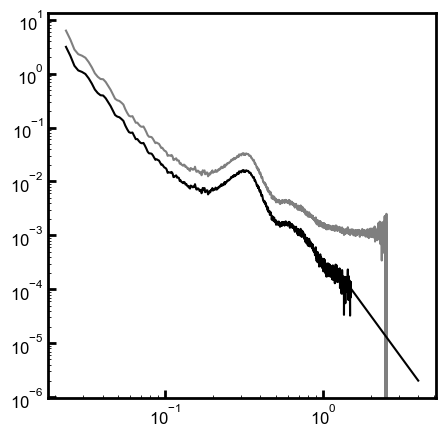

In [21]:
lim = 1.5
mask = q < lim

x, y = q[mask], (I[mask] - 0.85 * I[mask][-1])

x_porod = np.linspace(lim, 4, 1000)

y_porod = x_porod ** -4
y_porod /= y_porod[0]
y_porod *= np.mean(y[-10:-1]) / 1.1

q_full = np.concatenate([x, x_porod])
I_full = np.concatenate([y, y_porod])

plt.figure(figsize=(5,5))
plt.plot(q_full, I_full, zorder=1, alpha = 1, color='black')
plt.plot(q, I * 2, color='black', zorder=0, alpha=0.5)

plt.semilogx()
plt.semilogy()

(0.0, 2.0)

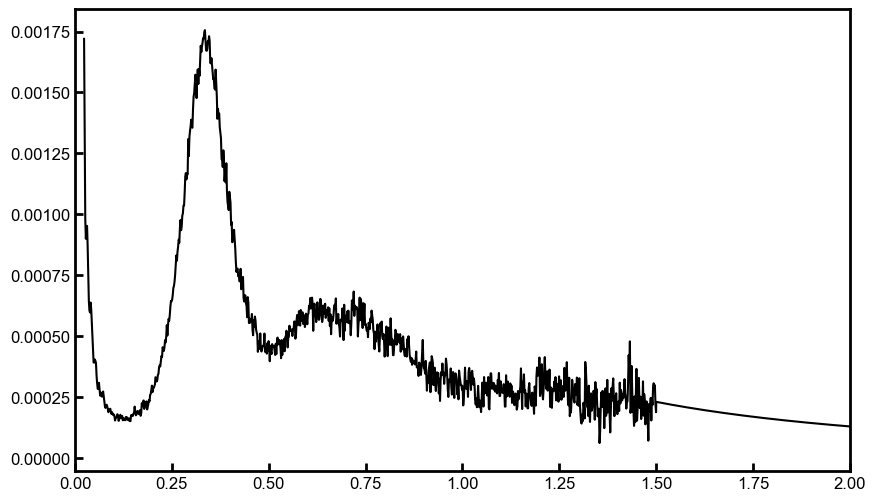

In [22]:
X, Y = q_full, I_full * q_full ** 2
plt.plot(X, Y, color='black')
plt.xlim(0, 2)

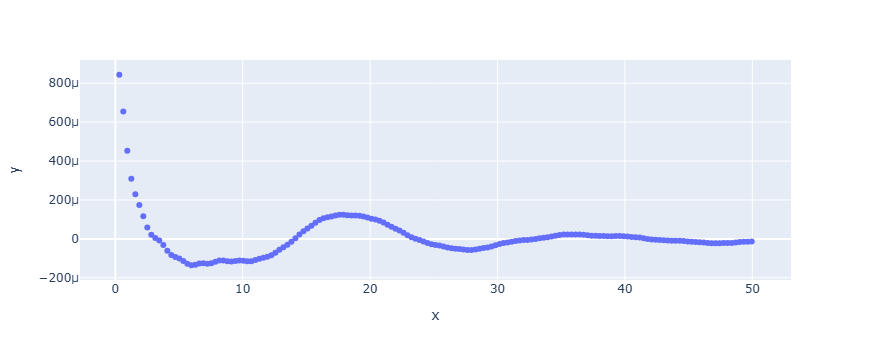

In [23]:
z, K = corr_func(X, Y, res = 5, zmax=50)
px.scatter(x=z, y=K)

L_p =  17.907078125461823
d =  15.700692060733447
Cr =  0.8767869303261068


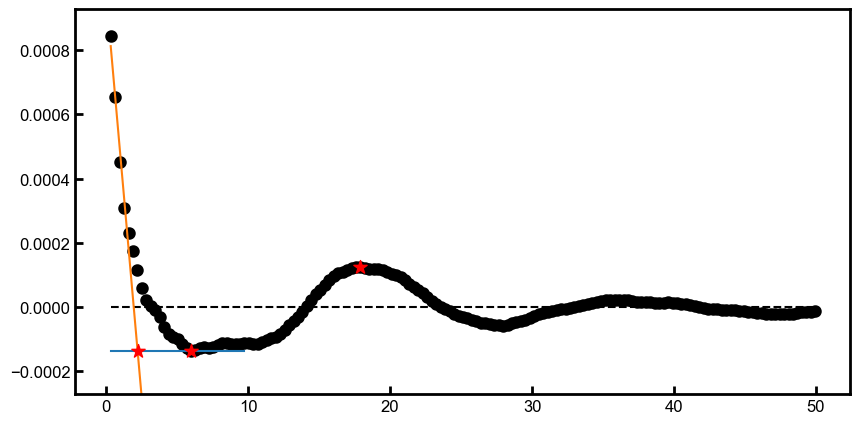

In [24]:
size = 100
plt.figure(figsize=(10,5))
plt.scatter(z, K, linewidth=3, color='black')
plt.plot(z, np.zeros(len(z)), linestyle='--', color='black')

mask_max = (z > 7) & (z < 25)
i_max = np.argmax(K[mask_max])
z_max = z[mask_max][i_max]
K_max = K[mask_max][i_max]
plt.scatter(z_max, K_max, zorder=10, color='red', marker='*', s=size)
print('L_p = ', z_max)

mask_min = (z > 0) & (z < 10)
i_min = np.argmin(K[mask_min])
z_min = z[mask_min][i_min]
K_min = K[mask_min][i_min]
plt.scatter(z_min, K_min, zorder=10, color='red', marker='*', s=size)

plt.plot(z[mask_min], K_min * np.ones(len(z[mask_min])))

mask_linear = z <1.8
p, cov = curve_fit(linear, z[mask_linear], K[mask_linear])

plt.plot(z[mask_min], linear(z[mask_min], *p))

plt.ylim(K_min * 2, max(K) * 1.1)

z_d = (K_min - p[1]) / p[0]
plt.scatter(z_d, linear(z_d, *p), zorder=10, color='red', marker='*', s=size)
print('d = ', z_max - z_d)

print('Cr = ', 1 - z_d / z_max)

[]

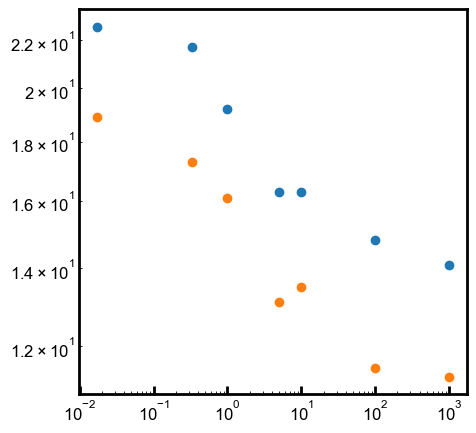

In [25]:
cool = [1000, 100, 10, 5, 1, 0.333, 0.017]
D = [14.1, 14.8, 16.3, 16.3, 19.2, 21.7, 22.6]
d = [11.3, 11.5, 13.5, 13.1, 16.1, 17.3, 18.9]

plt.figure(figsize=(5,5))
plt.scatter(cool, D)
plt.scatter(cool, d)

plt.semilogx()
plt.semilogy()

In [26]:
L = 390 * 0.125

# L / d[-1]
L

48.75

In [27]:
L / 8.6

5.6686046511627906

# Herman Factor

In [67]:
path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00296_00_azim.h5"

Exp = ID02_experiment(path)
theta, q, I = Exp.get_azim_data()

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_11288\3163839834.py:7: RuntimeWarning:

divide by zero encountered in log

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_11288\3163839834.py:7: RuntimeWarning:

invalid value encountered in log



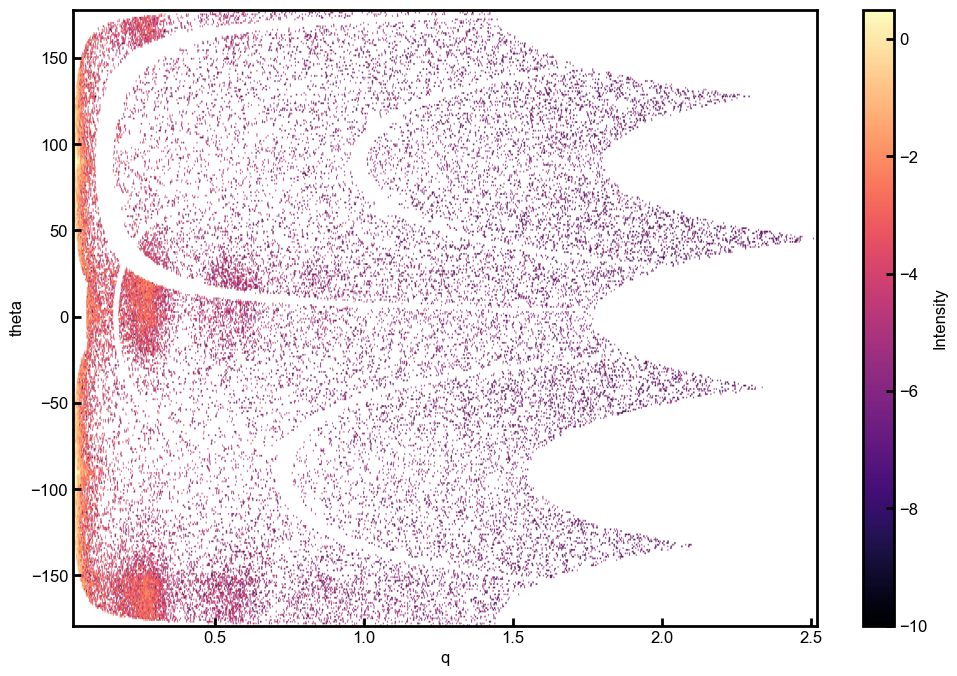

In [116]:
plt.figure(figsize=(12, 8))

vmin = -10
vmax = 0.5
cmap = plt.cm.magma.copy()
cmap.set_bad(color='white')
plt.imshow(np.log(I), vmin=vmin, vmax=vmax,aspect='auto', 
           extent=[q.min(), q.max(), theta.min(), theta.max()],
           origin='lower', cmap=cmap)
plt.colorbar(label='Intensity')
plt.xlabel('q')
plt.ylabel('theta')
plt.show()

In [79]:
def azim_line(q, I, q_peak):
    I_line = []
    index = np.argmin(np.abs(q - q_peak))

    for i in range(len(I)):
        I_line.append(I[i][index])

    return np.array(I_line)

[]

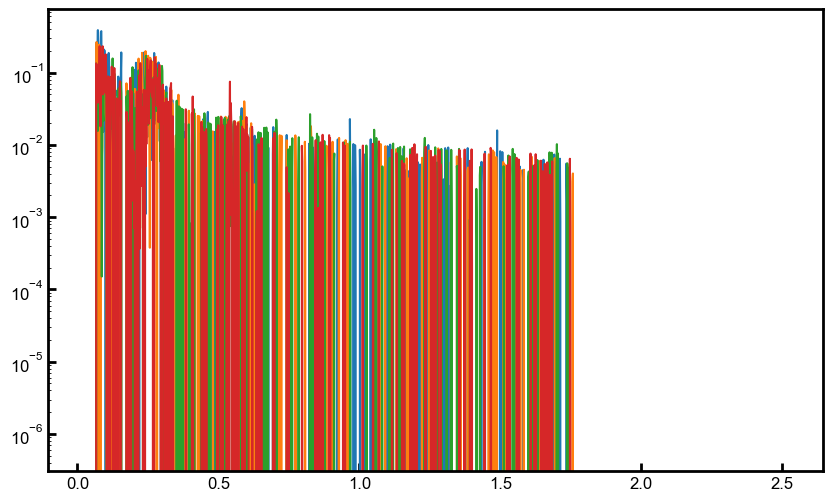

In [121]:
plt.plot(q, I[180])
plt.plot(q, I[181])
plt.plot(q, I[183])
plt.plot(q, I[182])
plt.semilogy()

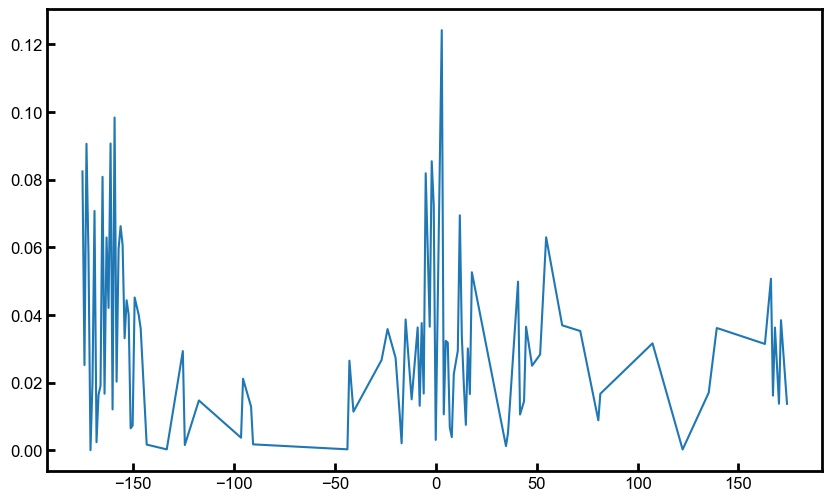

In [93]:
chi = np.array(range(360))
profile = azim_line(q, I, 0.3)

plt.plot(theta[profile>0], profile[profile>0])